<div style="background:linear-gradient(135deg,#083344 0%,#0e7490 55%,#06b6d4 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#a5f3fc;font-weight:700;text-transform:uppercase">Chapter 87 · Case Study · Inference</div>
  <div style="font-size:33px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: A Customer Satisfaction Survey 📝</div>
  <div style="font-size:15px;color:#ecfeff;max-width:760px;line-height:1.6">Survey data is gloriously mixed: a yes/no recommend, categorical plans, an ordinal 1-5 rating. We explore the categories first, then use statsmodels for the margin of error and scipy for the chi-square, Cramer's V, and the rank test.</div>
  <div style="margin-top:16px;font-size:13px;color:#a5f3fc">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
# statsmodels = the R/SAS-style stats library (pre-installed on Colab): it does the standard errors,
# test statistics, intervals, and post-hoc comparisons for us, so we write far less by-hand code.
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep, proportion_confint
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans
from scipy.stats.contingency import association   # Cramer's V in one call
CY="#0891b2"; DEEP="#0e7490"; LIGHT="#67e8f9"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
pd.set_option("display.width",120)
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(87)

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 1 · EXPLORE THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Counts, distributions, and a first look at the rating</div>
<div style="color:#4a5578;margin-top:6px">Survey data is categorical and ordinal, so 'explore' means counts and distributions, not just means. We check size and missingness, tabulate the categories, and look at the satisfaction histogram before choosing tests.</div>
</div>

In [2]:
try:    d = pd.read_excel("../../data/ch87_satisfaction_survey.xlsx", sheet_name="Responses")
except FileNotFoundError: d = pd.read_excel(BASE+"ch87_satisfaction_survey.xlsx", sheet_name="Responses")
print("shape:", d.shape, "| missing:", d.isna().sum().sum())
print("segment:", d.segment.value_counts().to_dict())
print("plan:   ", d.plan.value_counts().to_dict())
print(f"would-recommend overall: {d.would_recommend.mean():.1%}")
print("\nsatisfaction (1-5) counts:", d.satisfaction_1_5.value_counts().sort_index().to_dict())

shape: (720, 7) | missing: 0
segment: {'existing': 393, 'new': 327}
plan:    {'Basic': 359, 'Pro': 248, 'Enterprise': 113}
would-recommend overall: 64.3%

satisfaction (1-5) counts: {1: 12, 2: 56, 3: 189, 4: 265, 5: 198}


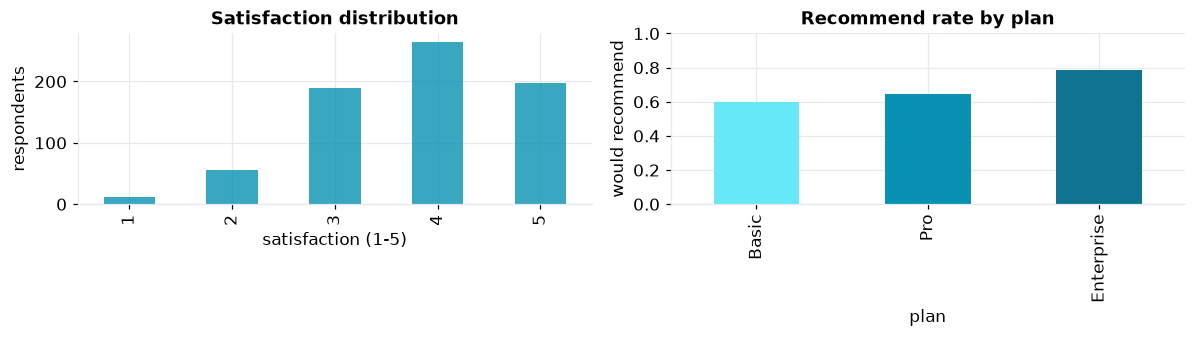

In [3]:
fig,ax=plt.subplots(1,2,figsize=(11,3.2))
d.satisfaction_1_5.value_counts().sort_index().plot(kind="bar", ax=ax[0], color=CY, alpha=0.8)
ax[0].set_xlabel("satisfaction (1-5)"); ax[0].set_ylabel("respondents"); ax[0].set_title("Satisfaction distribution")
d.groupby("plan").would_recommend.mean().reindex(["Basic","Pro","Enterprise"]).plot(kind="bar", ax=ax[1], color=[LIGHT,CY,DEEP])
ax[1].set_ylabel("would recommend"); ax[1].set_title("Recommend rate by plan"); ax[1].set_ylim(0,1)
plt.tight_layout(); plt.show()

Clean data, ratings cluster at 4-5 (a common ceiling), and recommend rate appears to climb with plan tier. Those first impressions now get tested properly, each with the right tool for its data type.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 2 · THREE QUESTIONS, THREE TESTS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A proportion, an association, and an ordinal comparison</div>
<div style="color:#4a5578;margin-top:6px">Q1 a single RATE -> proportion with a margin of error. Q2 two CATEGORICAL variables -> chi-square independence. Q3 an ORDINAL rating across two groups -> Mann-Whitney (ranks, because 1-5 is ordinal, not interval).</div>
</div>

In [4]:
print("Q1 share who would recommend    -> proportion + 95% margin of error")
print("Q2 plan vs would_recommend         -> CHI-SQUARE | H0: independent  H1: associated")
print("Q3 satisfaction: new vs existing   -> MANN-WHITNEY U (ordinal) | H0: same dist  H1: differ")

Q1 share who would recommend    -> proportion + 95% margin of error
Q2 plan vs would_recommend         -> CHI-SQUARE | H0: independent  H1: associated
Q3 satisfaction: new vs existing   -> MANN-WHITNEY U (ordinal) | H0: same dist  H1: differ


<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 3 · RUN THE ANALYSIS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">statsmodels for the interval and Cramer's V in one call each</div>
<div style="color:#4a5578;margin-top:6px">proportion_confint gives the margin of error, scipy's chi2_contingency runs the independence test, and scipy's association returns Cramer's V directly, no manual square roots.</div>
</div>

In [5]:
rec=d.would_recommend; n=len(rec)
lo,hi = proportion_confint(rec.sum(), n, method="normal")
print(f"Q1 recommend = {rec.mean():.1%}, 95% CI [{lo:.1%}, {hi:.1%}]  (margin of error +/- {(hi-lo)/2*100:.1f} pts)")
ct = pd.crosstab(d.plan, d.would_recommend)
chi2,p,dof,expected = stats.chi2_contingency(ct)
V = association(ct.values, method="cramer")
print(f"Q2 plan x recommend: chi2={chi2:.2f}, dof={dof}, p={p:.4f}, Cramer V={V:.3f}, min expected={expected.min():.1f}")
print("   -> reject H0: recommending depends on plan (but V is small -> a modest link)" if p<0.05 else "   independent")

Q1 recommend = 64.3%, 95% CI [60.8%, 67.8%]  (margin of error +/- 3.5 pts)
Q2 plan x recommend: chi2=13.74, dof=2, p=0.0010, Cramer V=0.138, min expected=40.3
   -> reject H0: recommending depends on plan (but V is small -> a modest link)


In [6]:
new=d[d.segment=="new"].satisfaction_1_5; ex=d[d.segment=="existing"].satisfaction_1_5
u,pu=stats.mannwhitneyu(new, ex, alternative="two-sided")
print(f"Q3 satisfaction: new mean={new.mean():.2f} (median {new.median():.0f}) vs existing mean={ex.mean():.2f} (median {ex.median():.0f})")
print(f"   Mann-Whitney U={u:.0f}, p={pu:.2e}  -> {'groups differ' if pu<0.05 else 'no difference'}")

Q3 satisfaction: new mean=3.58 (median 4) vs existing mean=3.99 (median 4)
   Mann-Whitney U=49469, p=2.47e-08  -> groups differ


The recommend rate is <strong>64% &#177; 3.5 points</strong> (so truly 61-68%). Recommending depends on plan (chi-square p &#8776; 0.001), but Cramer&#39;s V &#8776; 0.14 says the link is <em>modest</em>. And existing customers out-rate new ones (Mann-Whitney p &#8776; 10&#8315;&#8312;) even though both medians are 4, the rank test catches the distribution shift that equal medians hide.

<div style="background:#ffffff;border:1px solid #cffafe;border-left:5px solid #0e7490;border-radius:12px;padding:18px 22px;font-family:Inter,sans-serif">
<div style="font-size:12px;font-weight:800;color:#0e7490;letter-spacing:1px">📋 STATISTICIAN’S REPORT</div>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin:4px 0 8px">Read-out: a solid score, a clear lever, and an onboarding flag</div>
<div style="color:#3f4a63;line-height:1.75"><strong>What we found.</strong> About <strong>64%</strong> of customers would recommend us, give or take <strong>3.5 points</strong> (realistically 61-68%). Willingness to recommend <strong>rises with plan tier</strong> (statistically clear), and <strong>existing customers are more satisfied than new ones</strong> (a real gap). <br><br><strong>What it means.</strong> Quote the 64% as a range, not a point, and do not react to a one-to-two point wobble. The plan link is real but <em>modest</em> (Cramer&#39;s V &#8776; 0.14), so 'upsell to Pro' is a lever, not a cure. The new-versus-existing gap is the actionable signal. <br><br><strong>What to do.</strong> Track the recommend rate with its margin of error over time, and run a focused review of new-customer onboarding. <br><br><strong>Caveats.</strong> Surveys suffer non-response and self-selection, treat as directional. And satisfaction was compared by ranks, not averages, because a 1-5 scale is ordinal.</div>
</div>

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>